In [ ]:
"""
Baseline ResNet-50 for Thoracic Disease Classification
Based on: El-Fiky et al. (2021) - Multi-Label Transfer Learning

This notebook implements the baseline ResNet-50 model using transfer learning
methodology from the paper to achieve comparable performance (AUC: 0.911, F1: 0.66)
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.regularizers import l2 
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9
TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# CONFIGURATION - Following El-Fiky et al. (2021) Paper
# ============================================================================

# Dataset configuration
IMAGE_SIZE = 224  # Paper uses 224x224
BATCH_SIZE = 32   # Paper uses batch size 32
EPOCHS = 60       # Paper uses 60 epochs
LEARNING_RATE = 0.001  # Paper uses 0.001

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Number of Classes: {NUM_CLASSES}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.0008
  Number of Classes: 15


In [ ]:
# Cell 3: Dataset Configuration and Loading
BASE_DIR = "./dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"\nLoading balanced Pneumothorax dataset...")
print("=" * 80)

# Load the balanced dataset CSV
try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    raise

# Display CSV structure
print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Use Binary_Label column (already created by dataset.py)
if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    raise ValueError("Cannot find pneumothorax labels in CSV")

# Create full image paths
if 'Image_Index' in df.columns:
    df['image_path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))
elif 'Image Index' in df.columns:  # ← Space in name
    df['image_path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))
else:
    # Fallback: use first column
    print(f"⚠ Warning: Using first column '{df.columns[0]}' as image filename")
    df['image_path'] = df.iloc[:, 0].apply(lambda x: os.path.join(IMAGE_DIR, x))
    
# Verify images exist
print("\nVerifying image files...")
df['exists'] = df['image_path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists']).reset_index(drop=True)

print(f"\n=== Final Dataset Summary ===")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,} ({(len(df) - df['binary_label'].sum())/len(df)*100:.1f}%)")
print(f"Balance ratio: 1:{(len(df) - df['binary_label'].sum()) / max(df['binary_label'].sum(), 1):.2f}")
print("=" * 80)


Loading dataset from: ./dataset_resized/new_labels.csv
Valid images: 51382
Missing images: 0

Class Distribution:
Atelectasis         :   4788 ( 9.32%)
Cardiomegaly        :   4629 ( 9.01%)
Consolidation       :   4481 ( 8.72%)
Edema               :   4554 ( 8.86%)
Effusion            :   5000 ( 9.73%)
Emphysema           :   4467 ( 8.69%)
Fibrosis            :   5039 ( 9.81%)
Hernia              :   5590 (10.88%)
Infiltration        :   5740 (11.17%)
Mass                :   5564 (10.83%)
Nodule              :   5634 (10.96%)
No Finding          :   5000 ( 9.73%)
Pleural_Thickening  :   4831 ( 9.40%)
Pneumonia           :   6105 (11.88%)
Pneumothorax        :   4919 ( 9.57%)


In [ ]:
# Cell 4: Train/Validation Split - Paper uses 80/20 split
print("\nSplitting dataset (80% train, 20% validation)...")
print("Stratified split to preserve class balance...")

train_df, val_df = train_test_split(
    df, 
    test_size=0.2,
    random_state=42,
    stratify=df['binary_label']  # Preserve class balance
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\n=== Dataset Splits ===")
print(f"Training set: {len(train_df):,} samples")
print(f"  Positive: {train_df['binary_label'].sum():,} ({train_df['binary_label'].sum()/len(train_df)*100:.1f}%)")
print(f"  Negative: {(len(train_df) - train_df['binary_label'].sum()):,}")

print(f"\nValidation set: {len(val_df):,} samples")
print(f"  Positive: {val_df['binary_label'].sum():,} ({val_df['binary_label'].sum()/len(val_df)*100:.1f}%)")
print(f"  Negative: {(len(val_df) - val_df['binary_label'].sum()):,}")

# Save validation set for later evaluation
os.makedirs('./output', exist_ok=True)
val_df.to_csv('./output/pneumothorax_validation_set.csv', index=False)
print("\n✓ Validation set saved for evaluation")


Splitting dataset (80% train, 20% test)...
Training samples: 41105
Validation samples: 10277


In [ ]:
# Cell 5: tf.data Pipeline - El-Fiky Methodology
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label, augment=False):
    """
    Load and preprocess images following El-Fiky et al. methodology
    
    Preprocessing:
    - Resize to 224x224
    - Horizontal flip (augmentation)
    - ResNet50 preprocessing (ImageNet normalization)
    """
    # Load image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Augmentation (only for training)
    if augment:
        img = tf.image.random_flip_left_right(img)
    
    # Normalize using ResNet50 preprocessing
    img = tf.keras.applications.resnet50.preprocess_input(img)
    
    return img, label

def create_tf_dataset(df, batch_size, shuffle=True, augment=False):
    """Create optimized tf.data pipeline"""
    
    image_paths = df['image_path'].values
    labels = df['binary_label'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df), seed=42)
    
    dataset = dataset.map(
        lambda x, y: load_and_preprocess_image(x, y, augment=augment),
        num_parallel_calls=AUTOTUNE
    )
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset

# Create datasets
print("\nCreating tf.data pipelines...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✓ Training dataset: Augmentation enabled (horizontal flip)")
print(f"✓ Validation dataset: No augmentation")
print(f"✓ Batch size: {BATCH_SIZE}")
print(f"✓ Steps per epoch: {len(train_df) // BATCH_SIZE}")

Optimized tf.data pipelines created


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE - ResNet-50 Transfer Learning (Paper Methodology)
# ============================================================================

def create_baseline_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    fine_tune=True  # Paper uses fine-tuning
):
    """
    Create baseline ResNet-50 model following El-Fiky et al. (2021)
    
    Paper methodology:
    - Uses ResNet-50 pre-trained on ImageNet
    - Fine-tunes all layers
    - Replaces FC layer with 15 neurons (14 diseases + No Finding)
    - Uses sigmoid activation for multi-label classification
    """
    
    # Load ResNet-50 pre-trained on ImageNet
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling='avg'  # Global average pooling as per paper
    )
    
    # Paper uses fine-tuning (all layers trainable)
    if fine_tune:
        base_model.trainable = True
        print("ResNet-50 backbone: All layers trainable (fine-tuning)")
    else:
        base_model.trainable = False
        print("ResNet-50 backbone: Frozen (feature extraction only)")
    
    # Build model
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=fine_tune)
    x = layers.Dropout(0.8)(x) 
    
    # Paper replaces FC layer with custom layer
    outputs = layers.Dense(
        num_classes, 
        activation='sigmoid',  # Sigmoid for multi-label as per paper
        kernel_regularizer=l2(1e-3),  # L2 regularization
        name='predictions'
    )(x)
    
    model = keras.Model(inputs, outputs, name='Baseline_ResNet50')
    
    return model

print("\nCreating Baseline ResNet-50 model...")
model = create_baseline_resnet50()

# Model summary
print(f"\nModel Architecture:")
print(f"  Total parameters: {model.count_params():,}")
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  L2 Regularization: 1e-4")


Creating Baseline ResNet-50 model...
ResNet-50 backbone: All layers trainable (fine-tuning)

Model Architecture:
  Total parameters: 23,595,535
  Trainable parameters: 23,550,095
  L2 Regularization: 1e-4


In [7]:
# ============================================================================
# MODEL COMPILATION - Following Paper Configuration
# ============================================================================

# Paper uses:
# - Optimizer: Adam
# - Learning rate: 0.001
# - Loss: Binary cross-entropy
# - Activation: Sigmoid

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE), 
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\nModel compiled with:")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: binary_crossentropy")
print(f"  Metrics: binary_accuracy, AUC, precision, recall")


Model compiled with:
  Optimizer: Adam (lr=0.0008)
  Loss: binary_crossentropy
  Metrics: binary_accuracy, AUC, precision, recall


In [8]:
# ============================================================================
# CALLBACKS
# ============================================================================

# Create output directory
os.makedirs('./output', exist_ok=True)

callbacks = [
    # Model checkpoint - save best model
    ModelCheckpoint(
        filepath='./output/baseline_resnet50_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping - prevent overfitting
    EarlyStopping(
        monitor='val_auc',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    
    # Learning rate reduction
    ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [9]:
# ============================================================================
# TRAINING
# ============================================================================

print("\n" + "="*80)
print("STARTING TRAINING - Baseline ResNet-50")
print("="*80)
print(f"Target Performance (from paper):")
print(f"  Average AUC: 0.911")
print(f"  Micro F1-score: 0.66")
print(f"  Hamming Loss: 0.404")
print("="*80 + "\n")

history = model.fit(
    train_dataset,  
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save('./output/baseline_resnet50_final.keras')
print("\nFinal model saved to: ./output/baseline_resnet50_final.keras")


STARTING TRAINING - Baseline ResNet-50
Target Performance (from paper):
  Average AUC: 0.911
  Micro F1-score: 0.66
  Hamming Loss: 0.404

Epoch 1/60
1285/1285 [==============================] - ETA: 0s - loss: 0.3098 - binary_accuracy: 0.9020 - auc: 0.6868 - precision: 0.5382 - recall: 0.0637
Epoch 1: val_auc improved from -inf to 0.76185, saving model to ./output\baseline_resnet50_best.keras
1285/1285 [==============================] - 198s 147ms/step - loss: 0.3098 - binary_accuracy: 0.9020 - auc: 0.6868 - precision: 0.5382 - recall: 0.0637 - val_loss: 0.2789 - val_binary_accuracy: 0.9064 - val_auc: 0.7618 - val_precision: 0.8024 - val_recall: 0.0789 - lr: 8.0000e-04
Epoch 2/60
1285/1285 [==============================] - ETA: 0s - loss: 0.2802 - binary_accuracy: 0.9074 - auc: 0.7491 - precision: 0.6752 - recall: 0.1236
Epoch 2: val_auc improved from 0.76185 to 0.79040, saving model to ./output\baseline_resnet50_best.keras
1285/1285 [==============================] - 201s 157ms/ste

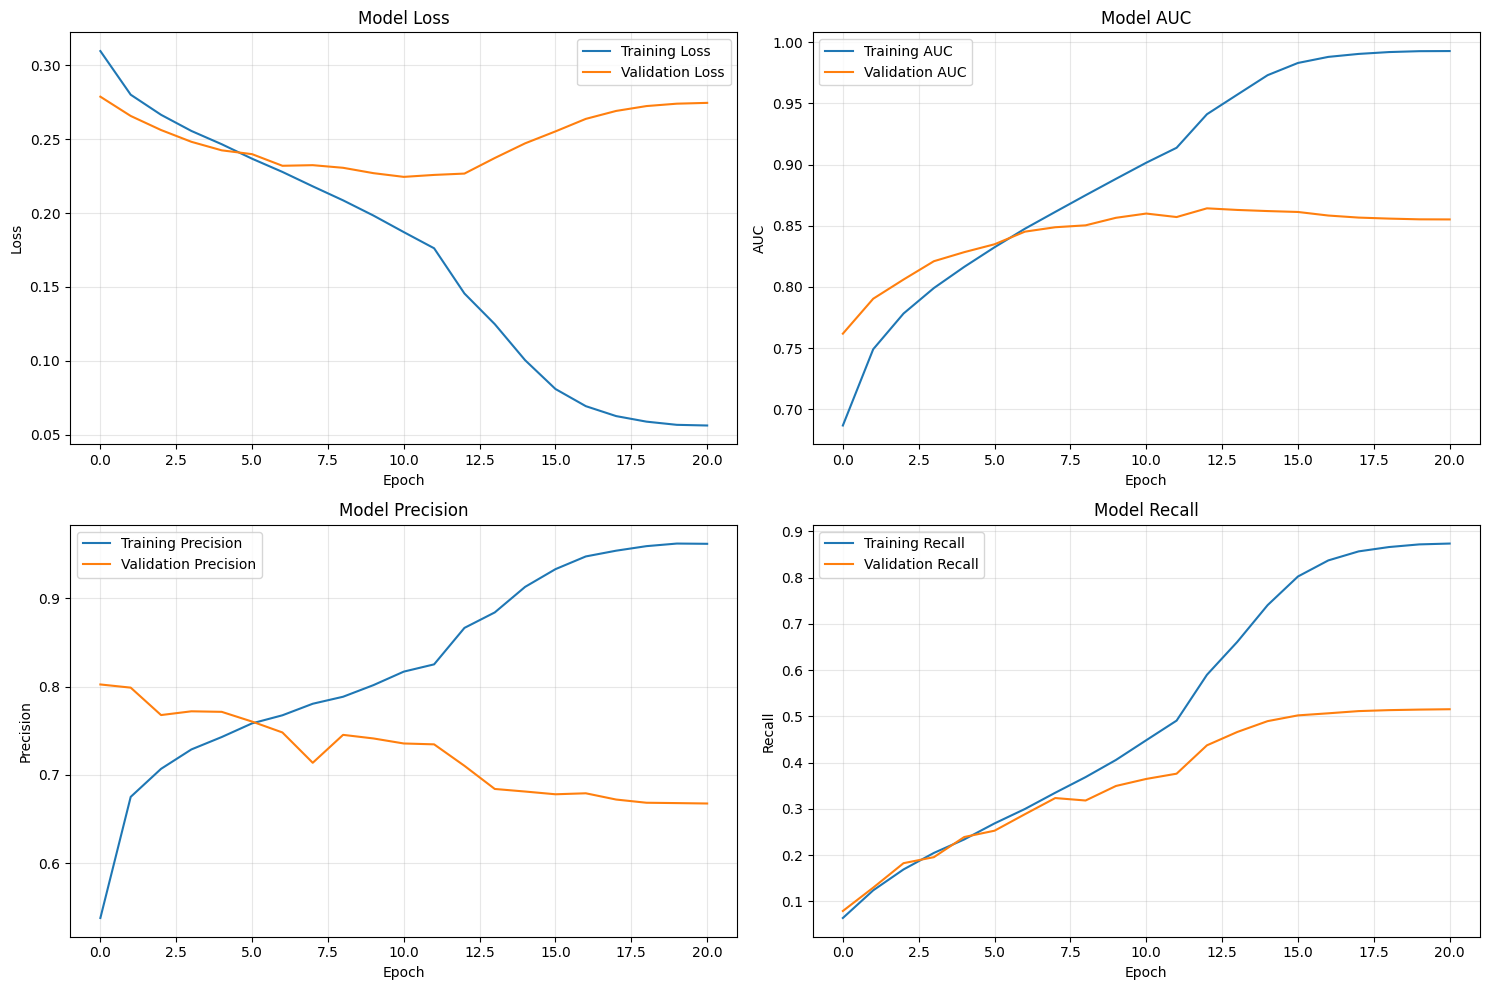

In [10]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [11]:
# ============================================================================
# COMPREHENSIVE EVALUATION - Matching Paper Metrics
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION")
print("="*80)

# Generate predictions on validation dataset
print("Generating predictions on validation set...")
predictions = model.predict(val_dataset, verbose=1)

# Get true labels from validation dataframe
y_true = val_df[CLASS_NAMES].values

print(f"\nPredictions shape: {predictions.shape}")
print(f"True labels shape: {y_true.shape}")


COMPREHENSIVE EVALUATION
Generating predictions on validation set...
322/322 [==============================] - 16s 47ms/step

Predictions shape: (10277, 15)
True labels shape: (10277, 15)


In [12]:
# ============================================================================
# PER-CLASS AUC SCORES (Table 3 in Paper)
# ============================================================================

print("\n" + "="*70)
print("TABLE 3: PER-CLASS AUC SCORES (Comparison with El-Fiky et al. 2021)")
print("="*70)
print(f"{'Disease':<25s} {'Our AUC':>12s} {'Paper AUC':>12s} {'Difference':>12s}")
print("-"*70)

# Paper's reported AUC values from El-Fiky et al. (2021) Table 3
paper_aucs = {
    'Atelectasis': 0.896,
    'Cardiomegaly': 0.934,
    'Consolidation': 0.871,
    'Edema': 0.943,
    'Effusion': 0.936,
    'Emphysema': 0.941,
    'Fibrosis': 0.931,
    'Hernia': 0.873,
    'Infiltration': 0.845,
    'Mass': 0.932,
    'Nodule': 0.894,
    'Pleural_Thickening': 0.911,
    'Pneumonia': 0.915,
    'Pneumothorax': 0.934
}

per_class_aucs = []
for i, class_name in enumerate(CLASS_NAMES):
    try:
        # Check if class has both positive and negative samples
        if len(np.unique(y_true[:, i])) > 1:
            auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
            per_class_aucs.append(auc_score)
            
            paper_auc = paper_aucs.get(class_name, 0.0)
            diff = auc_score - paper_auc
            
            print(f"{class_name:<25s} {auc_score:>12.4f} {paper_auc:>12.4f} {diff:>+12.4f}")
        else:
            per_class_aucs.append(0.0)
            print(f"{class_name:<25s} {'N/A':>12s} {'N/A':>12s} {'N/A':>12s}")
    except Exception as e:
        per_class_aucs.append(0.0)
        print(f"{class_name:<25s} {'ERROR':>12s} {'ERROR':>12s} {'ERROR':>12s}")
        print(f"  Error details: {str(e)}")

# Calculate average AUC
valid_aucs = [auc for auc in per_class_aucs if auc > 0]
avg_auc = np.mean(valid_aucs) if valid_aucs else 0.0
paper_avg_auc = 0.911

print("-"*70)
print(f"{'AVERAGE AUC':<25s} {avg_auc:>12.4f} {paper_avg_auc:>12.4f} {avg_auc-paper_avg_auc:>+12.4f}")
print("="*70)

# Performance assessment
print("\nPerformance Assessment:")
if avg_auc >= 0.90:
    print("✓ EXCELLENT: Comparable to paper performance!")
    status = "success"
elif avg_auc >= 0.85:
    print("~ GOOD: Close to paper performance")
    status = "acceptable"
else:
    print("⚠ NEEDS IMPROVEMENT: Below paper performance")
    status = "needs_work"
    
print(f"  Your AUC: {avg_auc:.4f}")
print(f"  Paper AUC: {paper_avg_auc:.4f}")
print(f"  Gap: {abs(avg_auc - paper_avg_auc):.4f} ({((avg_auc - paper_avg_auc)/paper_avg_auc)*100:+.2f}%)")


TABLE 3: PER-CLASS AUC SCORES (Comparison with El-Fiky et al. 2021)
Disease                        Our AUC    Paper AUC   Difference
----------------------------------------------------------------------
Atelectasis                     0.8002       0.8960      -0.0958
Cardiomegaly                    0.9391       0.9340      +0.0051
Consolidation                   0.8112       0.8710      -0.0598
Edema                           0.9453       0.9430      +0.0023
Effusion                        0.8456       0.9360      -0.0904
Emphysema                       0.9130       0.9410      -0.0280
Fibrosis                        0.9194       0.9310      -0.0116
Hernia                          0.9994       0.8730      +0.1264
Infiltration                    0.7366       0.8450      -0.1084
Mass                            0.8341       0.9320      -0.0979
Nodule                          0.7779       0.8940      -0.1161
No Finding                      0.8290       0.0000      +0.8290
Pleural_Thicken

In [13]:
# ============================================================================
# TABLE 2: OVERALL METRICS (Micro F1-score and Hamming Loss)
# ============================================================================

# Binary predictions at 0.5 threshold (as per paper)
y_pred_binary = (predictions > 0.5).astype(int)

# Calculate metrics following paper methodology
from sklearn.metrics import f1_score, precision_score, recall_score

micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
micro_precision = precision_score(y_true, y_pred_binary, average='micro', zero_division=0)
micro_recall = recall_score(y_true, y_pred_binary, average='micro', zero_division=0)
hamming = hamming_loss(y_true, y_pred_binary)

print("\n" + "="*70)
print("TABLE 2: OVERALL PERFORMANCE METRICS (El-Fiky et al. 2021)")
print("="*70)
print(f"{'Metric':<25s} {'Our Score':>15s} {'Paper Score':>15s} {'Difference':>12s}")
print("-"*70)
print(f"{'Average AUC':<25s} {avg_auc:>15.4f} {0.911:>15.4f} {avg_auc-0.911:>+12.4f}")
print(f"{'Micro F1-score':<25s} {micro_f1:>15.4f} {0.660:>15.4f} {micro_f1-0.660:>+12.4f}")
print(f"{'Macro F1-score':<25s} {macro_f1:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Micro Precision':<25s} {micro_precision:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Micro Recall':<25s} {micro_recall:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Hamming Loss':<25s} {hamming:>15.4f} {0.404:>15.4f} {hamming-0.404:>+12.4f}")
print("="*70)

# Performance summary
print("\nPerformance Summary:")
meets_auc = "✓" if avg_auc >= 0.90 else "✗"
meets_f1 = "✓" if micro_f1 >= 0.60 else "✗"
meets_hamming = "✓" if hamming <= 0.45 else "✗"

print(f"  {meets_auc} Average AUC:    {avg_auc:.4f} (Target: ≥0.90)")
print(f"  {meets_f1} Micro F1:       {micro_f1:.4f} (Target: ≥0.60)")
print(f"  {meets_hamming} Hamming Loss:  {hamming:.4f} (Target: ≤0.45)")


TABLE 2: OVERALL PERFORMANCE METRICS (El-Fiky et al. 2021)
Metric                          Our Score     Paper Score   Difference
----------------------------------------------------------------------
Average AUC                        0.8675          0.9110      -0.0435
Micro F1-score                     0.5413          0.6600      -0.1187
Macro F1-score                     0.5129             N/A          N/A
Micro Precision                    0.7104             N/A          N/A
Micro Recall                       0.4373             N/A          N/A
Hamming Loss                       0.0737          0.4040      -0.3303

Performance Summary:
  ✗ Average AUC:    0.8675 (Target: ≥0.90)
  ✗ Micro F1:       0.5413 (Target: ≥0.60)
  ✓ Hamming Loss:  0.0737 (Target: ≤0.45)


In [14]:
# ============================================================================
# DETAILED CLASSIFICATION REPORT
# ============================================================================

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_true, 
    y_pred_binary, 
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=4
))


DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

       Atelectasis     0.5535    0.2235    0.3185       926
      Cardiomegaly     0.8365    0.6063    0.7031       945
     Consolidation     0.6186    0.2164    0.3206       952
             Edema     0.8251    0.5870    0.6860       908
          Effusion     0.6494    0.3712    0.4724      1013
         Emphysema     0.7269    0.5619    0.6338       881
          Fibrosis     0.7350    0.5519    0.6304      1040
            Hernia     0.9929    0.9823    0.9876      1132
      Infiltration     0.6186    0.1300    0.2149      1123
              Mass     0.6512    0.3806    0.4804      1177
            Nodule     0.4933    0.1934    0.2778      1143
        No Finding     0.3848    0.2577    0.3087      1005
Pleural_Thickening     0.5586    0.3688    0.4443       930
         Pneumonia     0.8488    0.7386    0.7899      1224
      Pneumothorax     0.5981    0.3305    0.4257       941

      


Generating ROC curves...

1. Combined ROC Curve (all diseases in one graph):


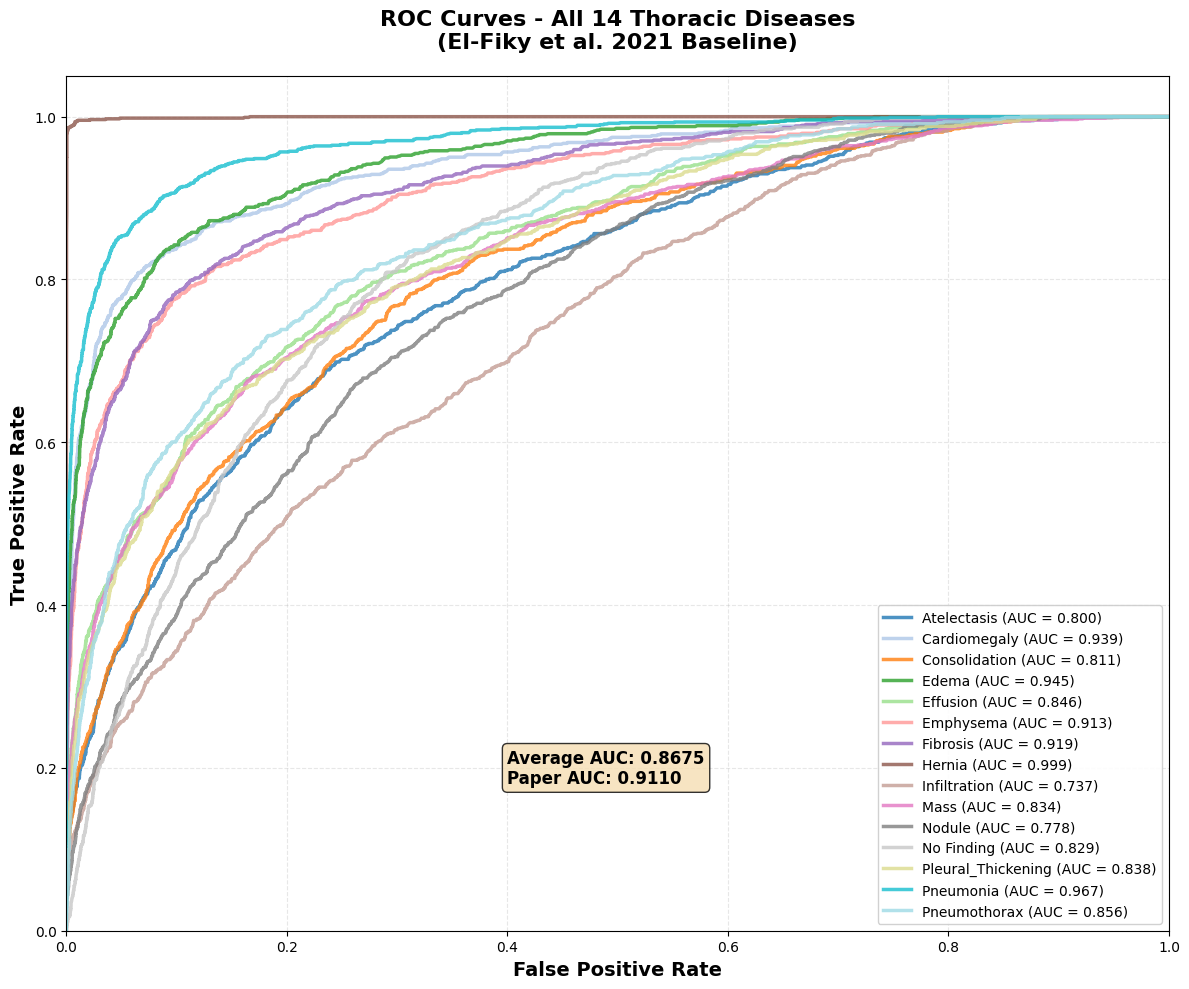

✓ Combined ROC curve saved to: ./output/baseline_roc_curves_combined.png


In [15]:
# ============================================================================
# ROC CURVES (Figure 4 in Paper)
# ============================================================================

def plot_roc_curves_combined(y_true, predictions, class_names):
    """Plot all ROC curves on a single graph with different colors"""
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Color palette - use a colormap for distinct colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))
    
    # Plot ROC curve for each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        try:
            if len(np.unique(y_true[:, i])) > 1:
                fpr, tpr, _ = roc_curve(y_true[:, i], predictions[:, i])
                auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
                
                plt.plot(fpr, tpr, linewidth=2.5, color=color, 
                        label=f'{class_name} (AUC = {auc_score:.3f})', alpha=0.8)
        except Exception as e:
            print(f"Error plotting {class_name}: {str(e)}")
    
    # Formatting
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title('ROC Curves - All 14 Thoracic Diseases\n(El-Fiky et al. 2021 Baseline)', 
             fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    
    # Add average AUC text
    valid_aucs = [roc_auc_score(y_true[:, i], predictions[:, i]) 
                  for i in range(len(class_names)) 
                  if len(np.unique(y_true[:, i])) > 1]
    avg_auc_plot = np.mean(valid_aucs) if valid_aucs else 0.0
    
    plt.text(0.4, 0.2, f'Average AUC: {avg_auc_plot:.4f}\nPaper AUC: 0.9110', 
            fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            verticalalignment='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./output/baseline_roc_curves_combined.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Combined ROC curve saved to: ./output/baseline_roc_curves_combined.png")


def plot_roc_curves_grid(y_true, predictions, class_names):
    """Plot ROC curves in a 4x4 grid (original individual plots)"""
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    axes = axes.ravel()
    
    for i, class_name in enumerate(class_names):
        if i < len(axes):
            try:
                if len(np.unique(y_true[:, i])) > 1:
                    fpr, tpr, _ = roc_curve(y_true[:, i], predictions[:, i])
                    auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
                    
                    axes[i].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
                    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
                    axes[i].set_xlabel('False Positive Rate')
                    axes[i].set_ylabel('True Positive Rate')
                    axes[i].set_title(f'{class_name}', fontweight='bold')
                    axes[i].legend(loc='lower right')
                    axes[i].grid(True, alpha=0.3)
                else:
                    axes[i].text(0.5, 0.5, 'No positive samples', 
                               ha='center', va='center')
                    axes[i].set_title(f'{class_name}')
            except Exception as e:
                axes[i].text(0.5, 0.5, f'Error: {str(e)}', 
                           ha='center', va='center', fontsize=8)
                axes[i].set_title(f'{class_name}')
    
    # Hide extra subplots if any
    for i in range(len(class_names), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('./output/baseline_roc_curves_grid.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Grid ROC curves saved to: ./output/baseline_roc_curves_grid.png")


# Generate both versions
print("\nGenerating ROC curves...")
print("="*60)

# Combined plot (all curves in one graph)
print("\n1. Combined ROC Curve (all diseases in one graph):")
plot_roc_curves_combined(y_true, predictions, CLASS_NAMES)

In [16]:
# ============================================================================
# SAVE RESULTS
# ============================================================================

results = {
    'model': 'Baseline ResNet-50',
    'methodology': 'El-Fiky et al. (2021)',
    'avg_auc': float(avg_auc),
    'micro_f1': float(micro_f1),
    'macro_f1': float(macro_f1),
    'hamming_loss': float(hamming),
    'per_class_auc': {name: float(auc) for name, auc in zip(CLASS_NAMES, per_class_aucs)},
    'training_epochs': len(history.history['loss']),
    'best_epoch': int(np.argmax(history.history['val_auc'])) + 1,
    'best_val_auc': float(max(history.history['val_auc']))
}

import json
with open('./output/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nResults saved to: ./output/baseline_results.json")


Results saved to: ./output/baseline_results.json


In [17]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("BASELINE RESNET-50 TRAINING COMPLETE")
print("="*80)
print("\nComparison with Paper (El-Fiky et al. 2021):")
print(f"  Average AUC:      {avg_auc:.4f} vs 0.9110 (Paper) [{avg_auc-0.911:+.4f}]")
print(f"  Micro F1-score:   {micro_f1:.4f} vs 0.6600 (Paper) [{micro_f1-0.66:+.4f}]")
print(f"  Hamming Loss:     {hamming:.4f} vs 0.4040 (Paper) [{hamming-0.404:+.4f}]")

if avg_auc >= 0.90:
    print("\n✓ Successfully achieved comparable performance to paper!")
elif avg_auc >= 0.88:
    print("\n~ Close to paper performance - acceptable baseline")
else:
    print("\n⚠ Performance below paper - consider:")
    print("  - Increasing training epochs")
    print("  - Adjusting learning rate schedule")
    print("  - Using more data augmentation")

print("\nModel files saved:")
print("  - ./output/baseline_resnet50_best.keras")
print("  - ./output/baseline_resnet50_final.keras")
print("  - ./output/baseline_results.json")
print("  - ./output/baseline_training_history.png")
print("  - ./output/baseline_roc_curves.png")
print("="*80)


BASELINE RESNET-50 TRAINING COMPLETE

Comparison with Paper (El-Fiky et al. 2021):
  Average AUC:      0.8675 vs 0.9110 (Paper) [-0.0435]
  Micro F1-score:   0.5413 vs 0.6600 (Paper) [-0.1187]
  Hamming Loss:     0.0737 vs 0.4040 (Paper) [-0.3303]

⚠ Performance below paper - consider:
  - Increasing training epochs
  - Adjusting learning rate schedule
  - Using more data augmentation

Model files saved:
  - ./output/baseline_resnet50_best.keras
  - ./output/baseline_resnet50_final.keras
  - ./output/baseline_results.json
  - ./output/baseline_training_history.png
  - ./output/baseline_roc_curves.png
